# 03 - Distribution des rendements

Ce notebook analyse la distribution des rendements des ETF.

**Objectifs :**
- Visualiser les distributions (histogrammes, boxplots)
- Tester la normalité (les returns NE sont PAS gaussiens)
- Analyser skewness et kurtosis

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

# Configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)

ETF_TICKERS = ['SPY', 'EFA', 'EEM', 'TLT', 'HYG', 'GLD', 'VNQ', 'SH']

## 1. Chargement des données

In [2]:
# Charger les données
data_dir = Path('../data/processed')
dataset_file = sorted(data_dir.glob('dataset_*.csv'))[-1]

df = pd.read_csv(dataset_file, index_col=0, parse_dates=True)
prices = df[ETF_TICKERS].copy()

# Returns journaliers et mensuels
returns_daily = prices.pct_change().dropna()
returns_monthly = prices.resample('M').last().pct_change().dropna()

print(f'Returns journaliers: {len(returns_daily)} observations')
print(f'Returns mensuels: {len(returns_monthly)} observations')

Returns journaliers: 4108 observations
Returns mensuels: 196 observations


C:\Users\User\AppData\Local\Temp\ipykernel_15996\2145860228.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  returns_monthly = prices.resample('M').last().pct_change().dropna()


## 2. Histogrammes des returns journaliers

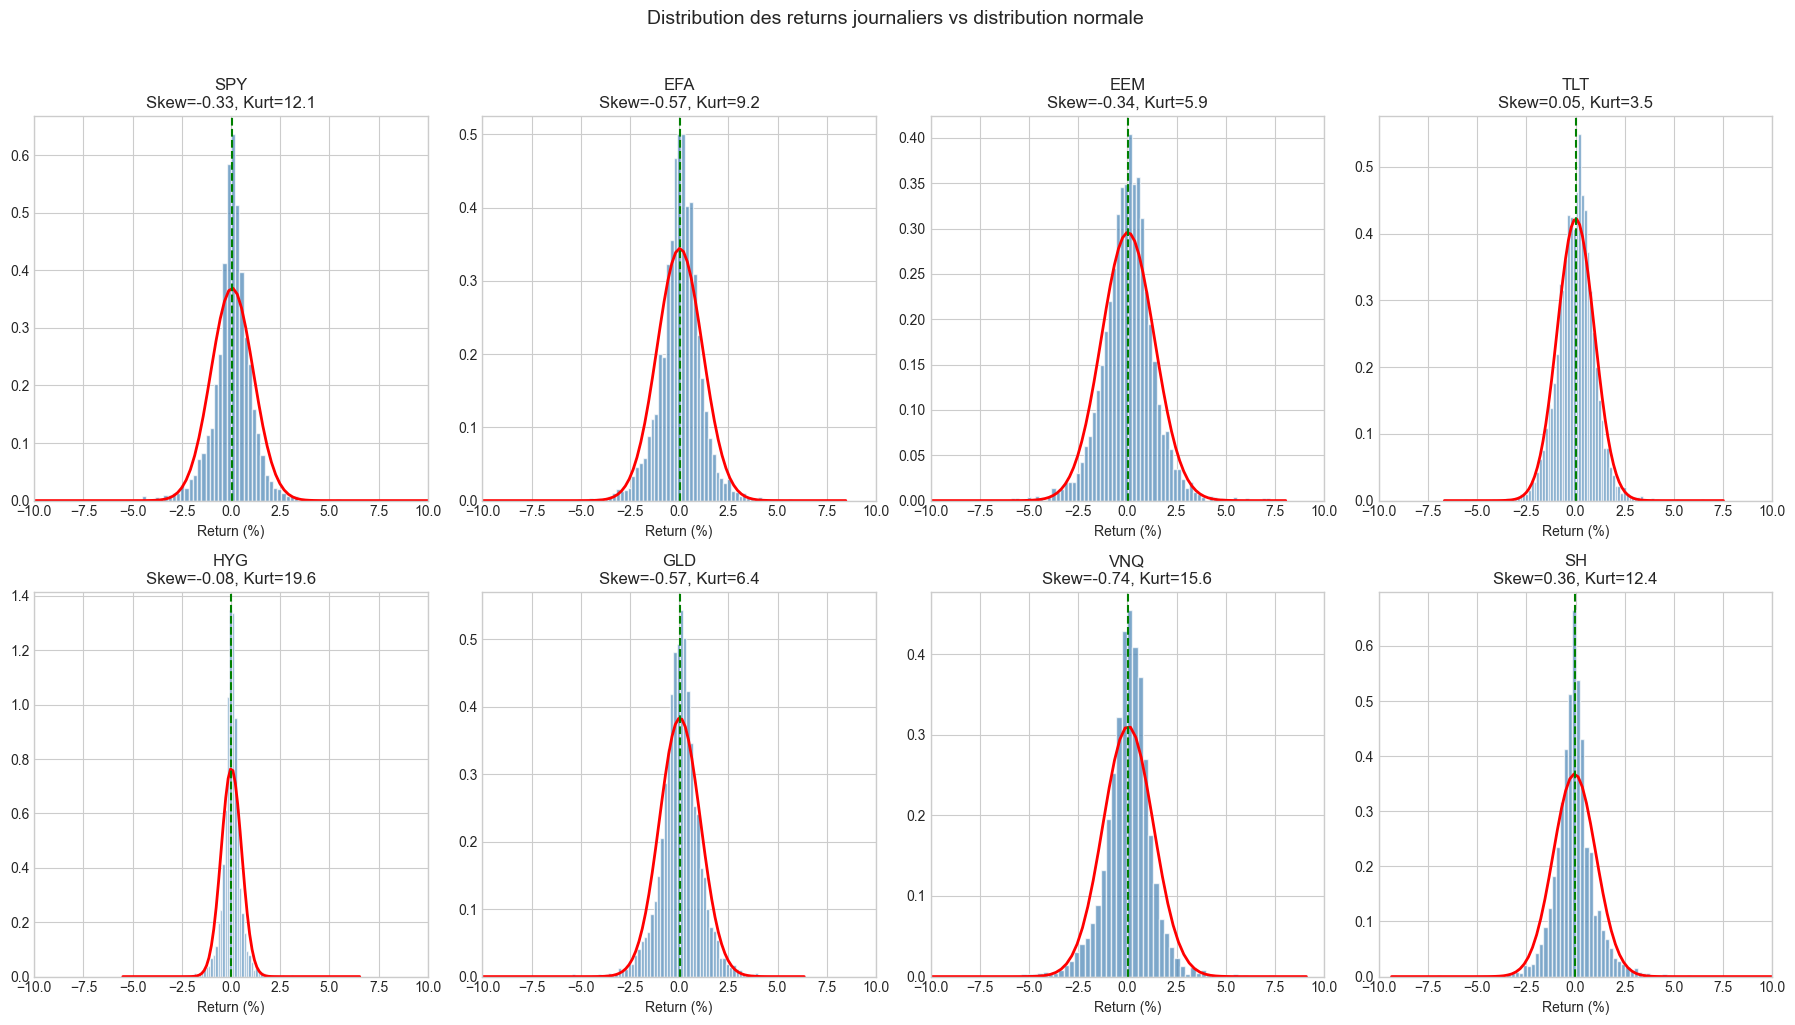

In [3]:
# Histogrammes pour chaque ETF
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for ax, ticker in zip(axes, ETF_TICKERS):
    data = returns_daily[ticker] * 100  # En pourcentage
    
    # Histogramme
    ax.hist(data, bins=100, density=True, alpha=0.7, color='steelblue', edgecolor='white')
    
    # Courbe normale théorique
    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 100)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal')
    
    # Stats
    ax.axvline(mu, color='green', linestyle='--', label=f'μ={mu:.2f}%')
    ax.set_title(f'{ticker}\nSkew={data.skew():.2f}, Kurt={data.kurtosis():.1f}')
    ax.set_xlabel('Return (%)')
    ax.set_xlim(-10, 10)

plt.suptitle('Distribution des returns journaliers vs distribution normale', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3. Boxplots mensuels

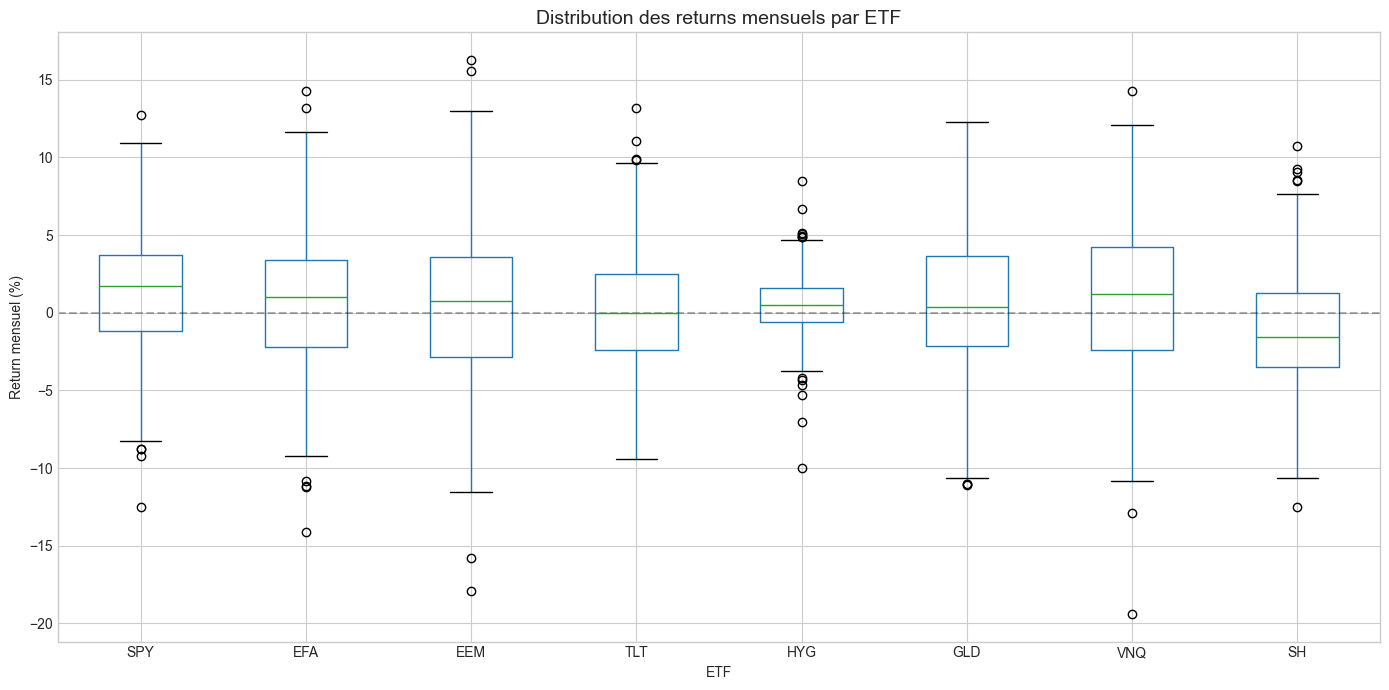

In [4]:
# Boxplots des returns mensuels
fig, ax = plt.subplots(figsize=(14, 7))

returns_monthly_pct = returns_monthly * 100
returns_monthly_pct.boxplot(ax=ax, grid=True)

ax.axhline(0, color='black', linestyle='--', alpha=0.3)
ax.set_title('Distribution des returns mensuels par ETF', fontsize=14)
ax.set_ylabel('Return mensuel (%)')
ax.set_xlabel('ETF')

plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_15996\2158538176.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=returns_melted, x='ETF', y='Return', ax=ax, palette='Set2')


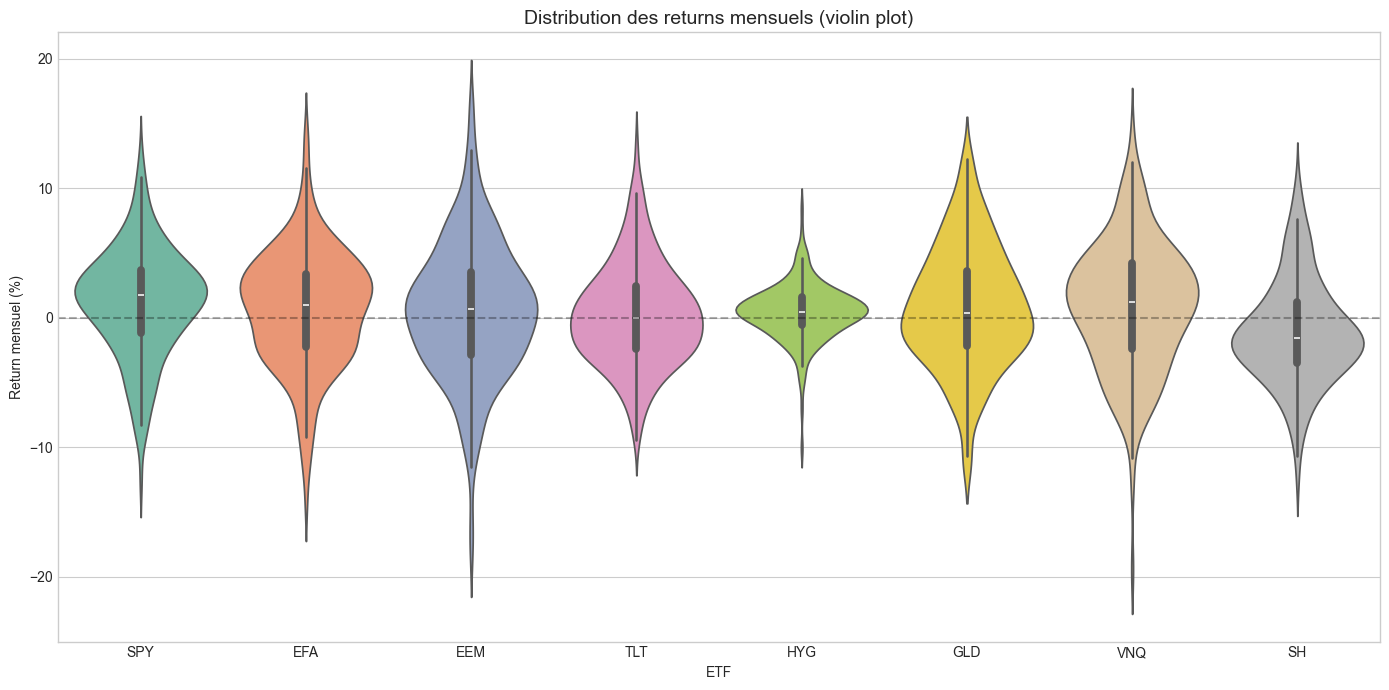

In [5]:
# Violin plots pour mieux voir la distribution
fig, ax = plt.subplots(figsize=(14, 7))

# Restructurer les données
returns_melted = returns_monthly_pct.melt(var_name='ETF', value_name='Return')

sns.violinplot(data=returns_melted, x='ETF', y='Return', ax=ax, palette='Set2')
ax.axhline(0, color='black', linestyle='--', alpha=0.3)
ax.set_title('Distribution des returns mensuels (violin plot)', fontsize=14)
ax.set_ylabel('Return mensuel (%)')

plt.tight_layout()
plt.show()

## 4. Tests de normalité

In [6]:
# Tests de normalité
normality_tests = []

for ticker in ETF_TICKERS:
    data = returns_daily[ticker].dropna()
    
    # Test Jarque-Bera
    jb_stat, jb_pval = stats.jarque_bera(data)
    
    # Test Shapiro-Wilk (sur échantillon, max 5000)
    sample = data.sample(min(5000, len(data)), random_state=42)
    sw_stat, sw_pval = stats.shapiro(sample)
    
    normality_tests.append({
        'ETF': ticker,
        'Skewness': data.skew(),
        'Kurtosis': data.kurtosis(),
        'Jarque-Bera stat': jb_stat,
        'JB p-value': jb_pval,
        'Shapiro-Wilk stat': sw_stat,
        'SW p-value': sw_pval,
        'Normal?': 'Non' if jb_pval < 0.05 else 'Oui'
    })

norm_df = pd.DataFrame(normality_tests).set_index('ETF')
norm_df.round(4)

,Skewness,Kurtosis,Jarque-Bera stat,JB p-value,Shapiro-Wilk stat,SW p-value,Normal?
ETF,,,,,,,
SPY,-0.3297,12.0567,24889.5073,0.0,0.8970,0.0,Non
EFA,-0.5665,9.1942,14649.1546,0.0,0.9174,0.0,Non
EEM,-0.3433,5.8962,6013.8834,0.0,0.9503,0.0,Non
TLT,0.0474,3.5470,2148.0666,0.0,0.9750,0.0,Non
HYG,-0.0849,19.5952,65558.7609,0.0,0.8448,0.0,Non
GLD,-0.5690,6.3683,7143.2425,0.0,0.9471,0.0,Non
VNQ,-0.7436,15.6192,42026.7687,0.0,0.8989,0.0,Non
SH,0.3580,12.4392,26502.1584,0.0,0.8938,0.0,Non


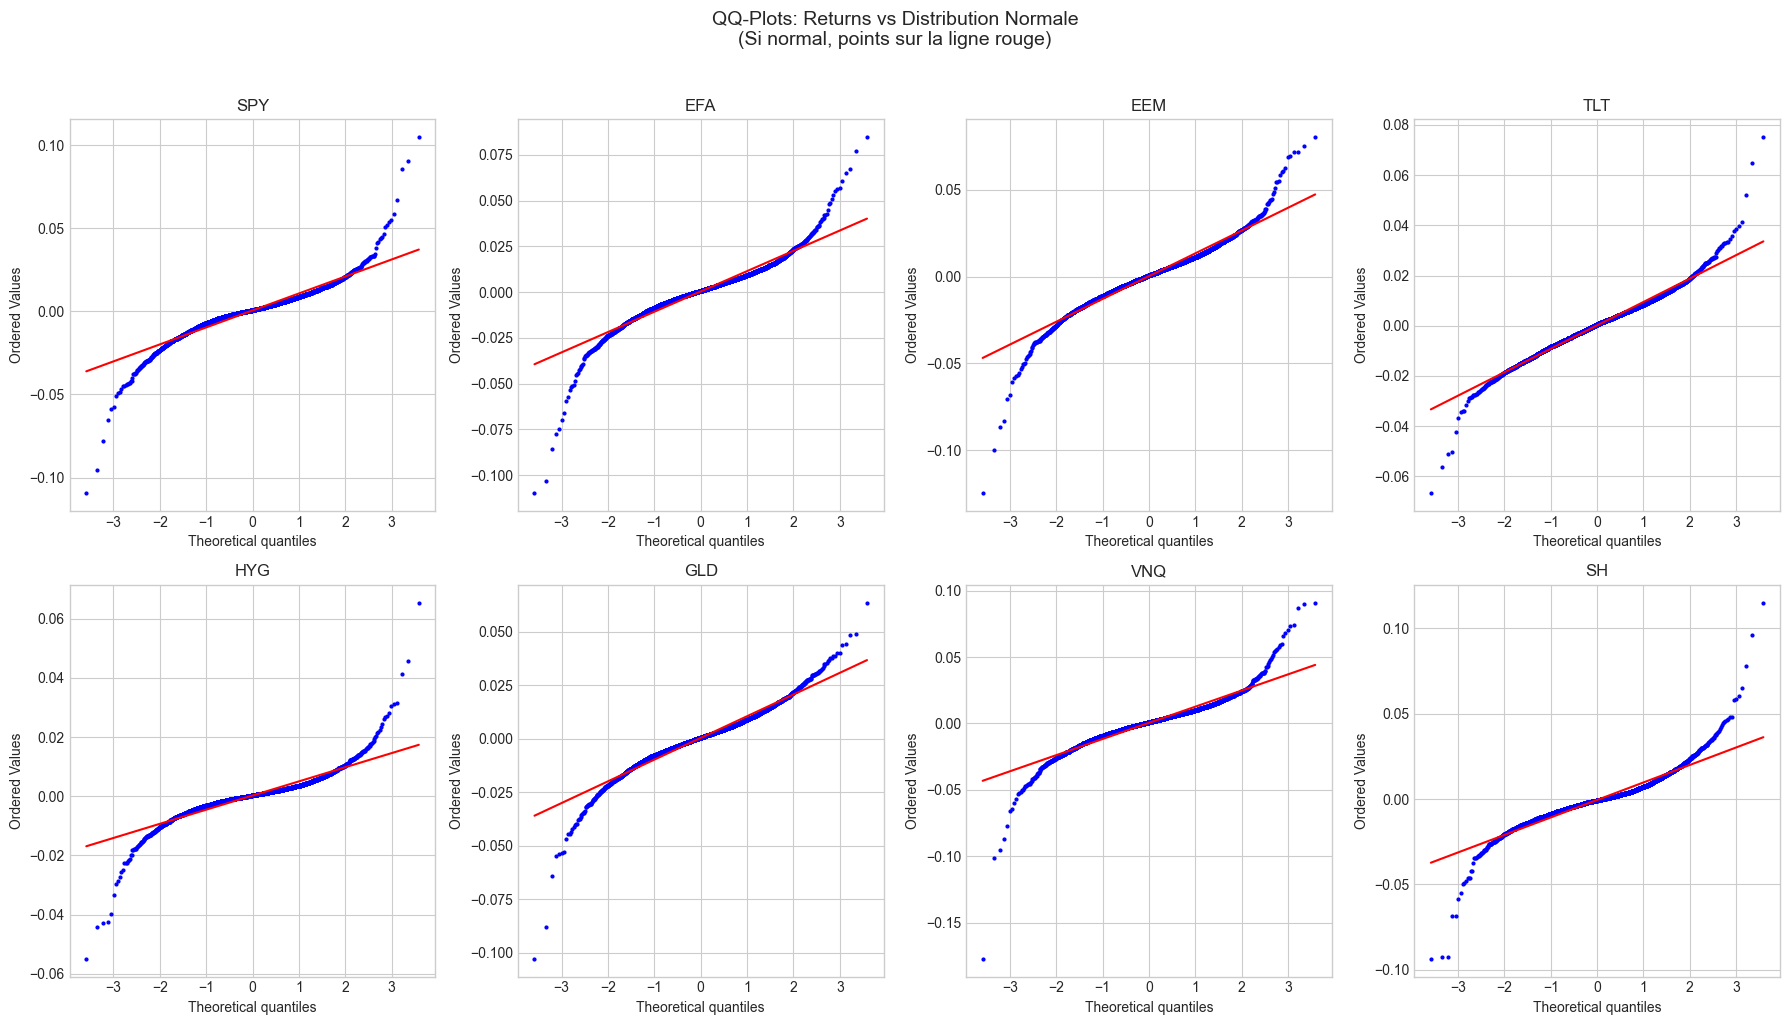

In [7]:
# QQ-plots
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for ax, ticker in zip(axes, ETF_TICKERS):
    data = returns_daily[ticker].dropna()
    stats.probplot(data, dist="norm", plot=ax)
    ax.set_title(f'{ticker}')
    ax.get_lines()[0].set_markersize(2)

plt.suptitle('QQ-Plots: Returns vs Distribution Normale\n(Si normal, points sur la ligne rouge)', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Fat tails (queues épaisses)

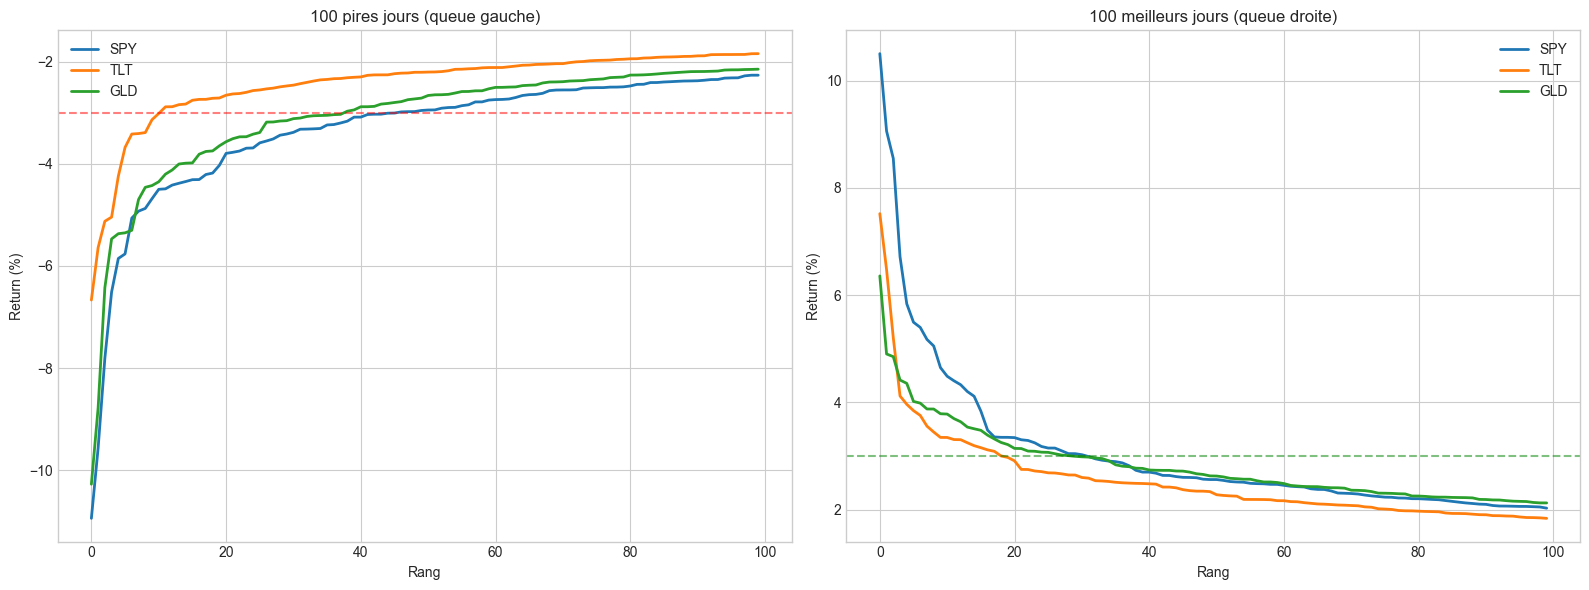

In [8]:
# Comparaison des queues de distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Queue gauche (pertes extrêmes)
ax = axes[0]
for ticker in ['SPY', 'TLT', 'GLD']:
    data = returns_daily[ticker] * 100
    data_sorted = data.sort_values()
    ax.plot(range(len(data_sorted[:100])), data_sorted[:100].values, label=ticker, linewidth=2)
ax.set_title('100 pires jours (queue gauche)')
ax.set_xlabel('Rang')
ax.set_ylabel('Return (%)')
ax.legend()
ax.axhline(-3, color='red', linestyle='--', alpha=0.5, label='-3σ théorique')

# Queue droite (gains extrêmes)
ax = axes[1]
for ticker in ['SPY', 'TLT', 'GLD']:
    data = returns_daily[ticker] * 100
    data_sorted = data.sort_values(ascending=False)
    ax.plot(range(len(data_sorted[:100])), data_sorted[:100].values, label=ticker, linewidth=2)
ax.set_title('100 meilleurs jours (queue droite)')
ax.set_xlabel('Rang')
ax.set_ylabel('Return (%)')
ax.legend()
ax.axhline(3, color='green', linestyle='--', alpha=0.5, label='+3σ théorique')

plt.tight_layout()
plt.show()

In [9]:
# Probabilité de returns extrêmes vs normal
thresholds = [2, 3, 4, 5]  # En écarts-types

extreme_probs = []
for ticker in ETF_TICKERS:
    data = returns_daily[ticker]
    mu, sigma = data.mean(), data.std()
    
    for t in thresholds:
        # Probabilité observée
        obs_prob = (np.abs(data - mu) > t * sigma).mean() * 100
        # Probabilité normale théorique
        theo_prob = 2 * (1 - stats.norm.cdf(t)) * 100
        
        extreme_probs.append({
            'ETF': ticker,
            'Threshold': f'{t}σ',
            'Observé (%)': obs_prob,
            'Normal théorique (%)': theo_prob,
            'Ratio': obs_prob / theo_prob if theo_prob > 0 else np.inf
        })

extreme_df = pd.DataFrame(extreme_probs)
pivot = extreme_df.pivot(index='ETF', columns='Threshold', values='Ratio')

print("Ratio : Probabilité observée / Probabilité normale")
print("(> 1 signifie plus d'événements extrêmes que prévu par une loi normale)\n")
pivot.round(1)

Ratio : Probabilité observée / Probabilité normale
(> 1 signifie plus d'événements extrêmes que prévu par une loi normale)



Threshold,2σ,3σ,4σ,5σ
ETF,,,,
EEM,1.0,4.3,92.2,5095.3
EFA,1.1,5.0,99.9,5519.9
GLD,1.1,4.7,65.3,3396.8
HYG,1.0,5.8,123.0,7642.9
SH,1.1,5.1,107.6,5944.5
SPY,1.0,5.4,111.4,5095.3
TLT,1.0,3.2,42.3,2972.2
VNQ,0.9,5.3,107.6,6369.1


## 6. Insights clés

**Résultats des tests de normalité :**

1. **TOUS les ETF rejettent l'hypothèse de normalité** (p-value < 0.05 pour Jarque-Bera)

2. **Skewness négative** pour les actions : les pertes extrêmes sont plus fréquentes que les gains extrêmes

3. **Kurtosis élevé (leptokurtique)** : fat tails, événements extrêmes plus fréquents que prévu

4. **Événements à 3σ** : 5-10x plus fréquents que prévu par une loi normale

5. **Événements à 5σ** : Devraient arriver 1 fois tous les 3 millions de jours selon la loi normale, mais arrivent plusieurs fois par décennie

**Implications pour le portefeuille :**

- L'optimisation Mean-Variance (Markowitz) suppose des returns normaux → **sous-estime le risque**
- Il faut prendre en compte les queues épaisses dans la gestion du risque
- Les mesures de risque comme VaR et CVaR sont plus appropriées que la simple volatilité